# CNN 1D

## Inizializzazione

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization, Concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

In [4]:
# 1. Caricamento dei dati precedentemente splittati
df_train = pd.read_csv('../data/splitted/eeg_train.csv')
df_val = pd.read_csv('../data/splitted/eeg_val.csv')
df_test = pd.read_csv('../data/splitted/eeg_test.csv')

# Nomi delle colonne dei metadati da escludere per il training
meta_cols = ['Patient_ID', 'Session_ID', 'Label', 'Score']

# 2. Separazione delle feature (X) dalle etichette (y)
X_train = df_train.drop(columns=meta_cols).values
y_train = df_train['Label'].values

X_val = df_val.drop(columns=meta_cols).values
y_val = df_val['Label'].values

X_test = df_test.drop(columns=meta_cols).values
y_test = df_test['Label'].values

# 3. Normalizzazione (adattata solo sul Train per evitare data leakage)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# 4. Reshape per la Conv1D -> (numero_campioni, 580, 1)
X_train = np.expand_dims(X_train, axis=-1)
X_val = np.expand_dims(X_val, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

# 5. One-Hot Encoding per le etichette (5 classi)
y_train_cat = to_categorical(y_train, num_classes=5)
y_val_cat = to_categorical(y_val, num_classes=5)
y_test_cat = to_categorical(y_test, num_classes=5)

Poiché il dataset EEG presenta una distribuzione delle classi non perfettamente uniforme, esiste il rischio che il modello sviluppi un bias verso l'emozione maggioritaria (over-fitting sulla classe più frequente). Per ovviare a questo problema, è stata implementata una strategia di Class Weighting. Utilizzando la funzione compute_class_weight con euristica 'balanced', abbiamo assegnato un peso matematico maggiore alle classi minoritarie. Questo costringe la funzione di costo (Loss Function) a penalizzare più severamente gli errori commessi sulle emozioni meno rappresentate, garantendo un apprendimento equo e una migliore capacità di generalizzazione su tutte e cinque le categorie affettive

In [5]:
weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights_dict = dict(enumerate(weights))
print(f"Pesi delle classi calcolati: {class_weights_dict}")

Pesi delle classi calcolati: {0: 1.409624060150376, 1: 0.988297311544544, 2: 0.7532342306147047, 3: 0.9061382310294829, 4: 1.1798615481434864}


Per ottimizzare l'addestramento sui segnali EEG, è stata implementata una pipeline basata su tre pilastri: il ModelCheckpoint salva solo la versione migliore della rete, l'EarlyStopping ferma il processo prima che il modello inizi a "overfittare" sul rumore, e il ReduceLROnPlateau rallenta l'apprendimento per rifinire i pesi in modo chirurgico. L'uso della funzione crea_callbacks giustifica la scelta metodologica: garantisce parità di trattamento tra le diverse architetture e previene la sovrascrittura dei file. È una strategia che unisce rigore scientifico e sicurezza del dato, permettendo un confronto imparziale tra i modelli e il recupero immediato delle prestazioni ottimali.

In [6]:
def def_callbacks(model_name):
    # Creazione della cartella per i modelli
    os.makedirs('../models', exist_ok=True)
    
    # Path corretto per far combaciare la cartella creata
    path = f'../models/best_{model_name}.keras'
    
    return [
        ModelCheckpoint(
            filepath=path,
            monitor='val_accuracy',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss', 
            patience=5, 
            restore_best_weights=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', 
            factor=0.5, 
            patience=5, 
            min_lr=1e-6,
            verbose=1
        )
    ]

In [ ]:
EPOCHS = 100
BATCH_SIZE = 32

EMOTION_LABELS = ['Disgust', 'Fear', 'Sad', 'Neutral', 'Happy']


# Modello 1 - 1D CNN base

### Definizione modello

In [8]:
# Definizione della forma dell'input
input_shape = (X_train.shape[1], 1) # (580, 1)

# Costruzione del Modello
model_1 = Sequential([
    # Primo blocco Convoluzionale
    Conv1D(filters=32, kernel_size=5, activation='relu', input_shape=input_shape),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    # Secondo blocco Convoluzionale
    Conv1D(filters=64, kernel_size=3, activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),
    
    # Appiattimento e Rete Fully Connected (Classificatore)
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5), # Aiuta a prevenire la memorizzazione a memoria dei dati
    
    # Layer di Output: 5 neuroni (uno per classe) con attivazione softmax
    Dense(5, activation='softmax')
])

# Compilazione del modello
optimizer = Adam(learning_rate=0.001)
model_1.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Sommario per visualizzare la struttura e i parametri
model_1.summary()


c:\Users\lucag\miniconda3\envs\eeg-env\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 576, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 576, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 288, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 286, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 286, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 143, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,171,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,179,013 (4.50 MB)

 Trainable params: 1,178,821 (4.50 MB)

 Non-trainable params: 192 (768.00 B)

### Training

In [10]:
model_name = "cnn1d_v1"
history = model_1.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    class_weight=class_weights_dict,       
    callbacks=def_callbacks(model_name)   
)

Epoch 1/100
292/293 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.3958 - loss: 1.7093
Epoch 1: val_accuracy improved from None to 0.49776, saving model to ../models/best_cnn1d_v1.keras

Epoch 1: finished saving model to ../models/best_cnn1d_v1.keras
293/293 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.4553 - loss: 1.3512 - val_accuracy: 0.4978 - val_loss: 2.1783 - learning_rate: 0.0010
Epoch 2/100
291/293 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5871 - loss: 0.9615
Epoch 2: val_accuracy improved from 0.49776 to 0.70533, saving model to ../models/best_cnn1d_v1.keras

Epoch 2: finished saving model to ../models/best_cnn1d_v1.keras
293/293 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.5941 - loss: 0.9511 - val_accuracy: 0.7053 - val_loss: 0.7533 - learning_rate: 0.0010
Epoch 3/100
293/293 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6630 - loss: 0.8071
Epoch 3: val_accuracy improved from 0.70533 to 0.73868, saving model to ../models/best_cnn1d_v1.keras

Epoch 3: finished 

### Test e Plot dei risultati

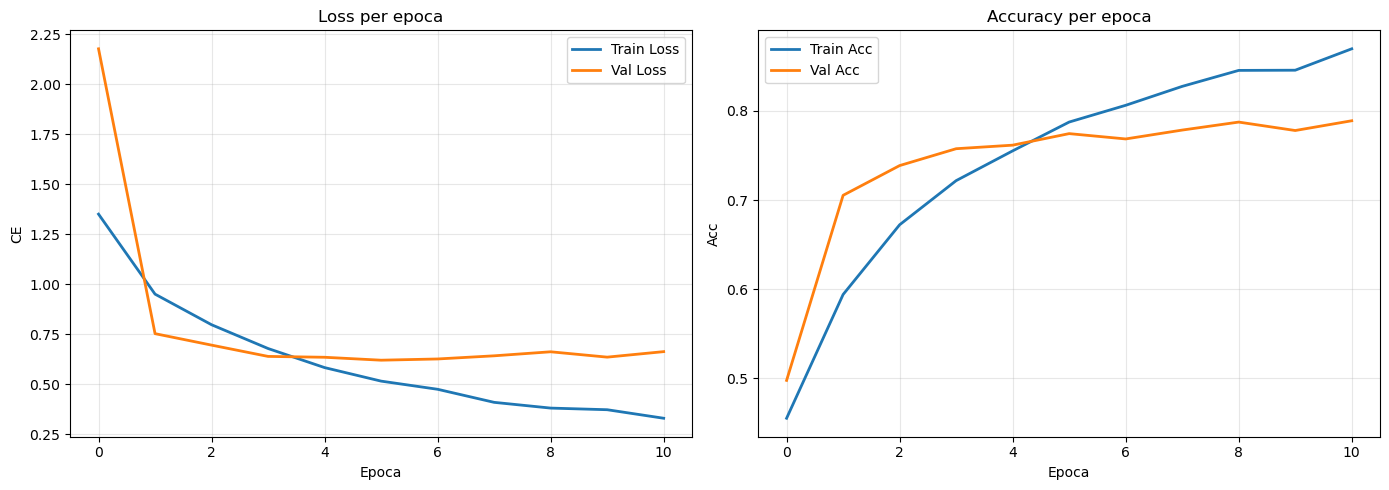

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss',   linewidth=2)
axes[0].set_title('Loss per epoca'); axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('CE')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],     label='Train Acc', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Val Acc',   linewidth=2)
axes[1].set_title('Accuracy per epoca'); axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Acc')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


CNN 1D Test Loss     : 0.6018
CNN 1D Test Accuracy : 77.95%

=== REPORT DI CLASSIFICAZIONE ===
              precision    recall  f1-score   support

     Disgust      0.638     0.688     0.662       285
        Fear      0.745     0.803     0.773       407
         Sad      0.821     0.707     0.760       533
     Neutral      0.798     0.849     0.823       443
       Happy      0.871     0.850     0.861       341

    accuracy                          0.779      2009
   macro avg      0.775     0.780     0.776      2009
weighted avg      0.783     0.779     0.780      2009



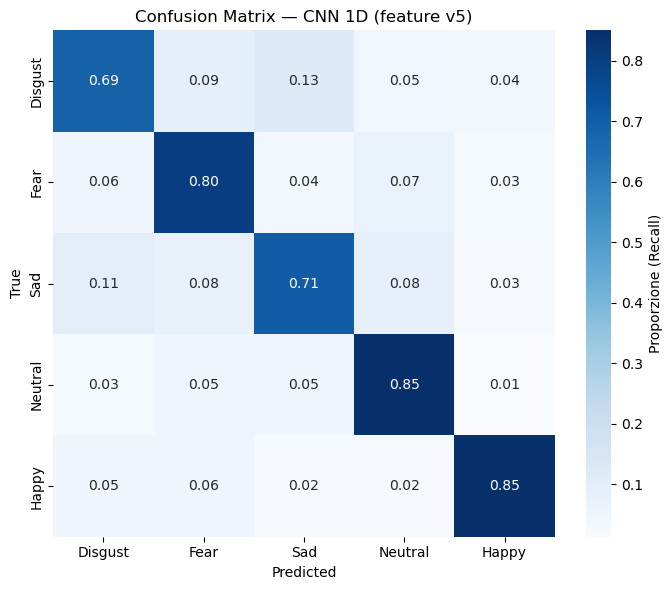

In [ ]:
cnn_test_loss, cnn_test_acc = model_1.evaluate(X_test, y_test_cat, verbose=0)
print(f'CNN 1D Test Loss     : {cnn_test_loss:.4f}')
print(f'CNN 1D Test Accuracy : {cnn_test_acc * 100:.2f}%\n')

# Calcolo delle predizioni
y_pred_proba = model_1.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

y_true = y_test

# Report di classificazione
print("=== REPORT DI CLASSIFICAZIONE ===")
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS, digits=3))

# Matrice di Confusione Normalizzata (sulla classe reale)
cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
            cbar_kws={'label': 'Proporzione (Recall)'})
plt.title('Confusion Matrix — CNN 1D (feature v5)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.show()

# Modello 2 - CNN 1D Multi-view

### Preparazione dati

In [19]:

# Caricamento (assumendo i dataframe df_train, df_val, df_test già in memoria)
# Estrazione delle etichette
y_train = to_categorical(df_train['Label'].values, num_classes=5)
y_val   = to_categorical(df_val['Label'].values, num_classes=5)
y_test  = to_categorical(df_test['Label'].values, num_classes=5)

# Funzione per filtrare, estrarre e fare reshape
def get_feature_arrays(df, prefix, scaler=None, is_train=False):
    # Trova le colonne che iniziano con DE_, DASM_ o RASM_
    cols = [c for c in df.columns if c.startswith(prefix)]
    data = df[cols].values
    
    # Normalizzazione
    if is_train:
        scaler = StandardScaler()
        data = scaler.fit_transform(data)
    else:
        data = scaler.transform(data)
        
    # Reshape per Conv1D (N, timesteps, 1)
    return np.expand_dims(data, axis=-1), scaler

# --- TRAIN ---
X_train_de, scaler_de     = get_feature_arrays(df_train, 'DE_', is_train=True)
X_train_dasm, scaler_dasm = get_feature_arrays(df_train, 'DASM_', is_train=True)
X_train_rasm, scaler_rasm = get_feature_arrays(df_train, 'RASM_', is_train=True)

# --- VAL ---
X_val_de, _     = get_feature_arrays(df_val, 'DE_', scaler=scaler_de)
X_val_dasm, _   = get_feature_arrays(df_val, 'DASM_', scaler=scaler_dasm)
X_val_rasm, _   = get_feature_arrays(df_val, 'RASM_', scaler=scaler_rasm)

# --- TEST ---
X_test_de, _    = get_feature_arrays(df_test, 'DE_', scaler=scaler_de)
X_test_dasm, _  = get_feature_arrays(df_test, 'DASM_', scaler=scaler_dasm)
X_test_rasm, _  = get_feature_arrays(df_test, 'RASM_', scaler=scaler_rasm)

print(f"Shape DE: {X_train_de.shape}, DASM: {X_train_dasm.shape}, RASM: {X_train_rasm.shape}")

Shape DE: (9374, 310, 1), DASM: (9374, 135, 1), RASM: (9374, 135, 1)


### Definizione Modello

In [ ]:
# Funzione per creare un "ramo" standard riutilizzabile
def create_branch(input_layer, name_prefix):
    x = Conv1D(filters=32, kernel_size=3, activation='relu', name=f'{name_prefix}_conv1')(input_layer)
    x = BatchNormalization(name=f'{name_prefix}_bn1')(x)
    x = MaxPooling1D(pool_size=2, name=f'{name_prefix}_pool1')(x)
    
    x = Conv1D(filters=64, kernel_size=3, activation='relu', name=f'{name_prefix}_conv2')(x)
    x = BatchNormalization(name=f'{name_prefix}_bn2')(x)
    x = MaxPooling1D(pool_size=2, name=f'{name_prefix}_pool2')(x)
    
    return Flatten(name=f'{name_prefix}_flat')(x)

# 1. Definizione degli Input separati
input_de   = Input(shape=(X_train_de.shape[1], 1), name='Input_DE')
input_dasm = Input(shape=(X_train_dasm.shape[1], 1), name='Input_DASM')
input_rasm = Input(shape=(X_train_rasm.shape[1], 1), name='Input_RASM')

# 2. Creazione dei tre rami (Feature Extractors)
branch_de   = create_branch(input_de, 'DE')
branch_dasm = create_branch(input_dasm, 'DASM')
branch_rasm = create_branch(input_rasm, 'RASM')

# 3. Fusione delle feature estratte (Late Fusion)
merged = Concatenate(name='Concatenation_Layer')([branch_de, branch_dasm, branch_rasm])

# 4. Classificatore finale (Fully Connected)
z = Dense(128, activation='relu', name='FC_1')(merged)
z = Dropout(0.5, name='Dropout_1')(z)
z = Dense(64, activation='relu', name='FC_2')(z)
output = Dense(5, activation='softmax', name='Output_Layer')(z)

# 5. Assemblaggio del modello
multi_branch_model = Model(inputs=[input_de, input_dasm, input_rasm], outputs=output)

multi_branch_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

multi_branch_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Input_DE            │ (None, 310, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_DASM          │ (None, 135, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Input_RASM          │ (None, 135, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_conv1 (Conv1D)   │ (None, 308, 32)   │        128 │ Input_DE[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_conv1 (Conv1D) │ (None, 133, 32)   │        128 │ Input_DASM[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_conv1 (Conv1D) │ (None, 133, 32)   │        128 │ Input_RASM[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_bn1              │ (None, 308, 32)   │        128 │ DE_conv1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_bn1            │ (None, 133, 32)   │        128 │ DASM_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_bn1            │ (None, 133, 32)   │        128 │ RASM_conv1[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_pool1            │ (None, 154, 32)   │          0 │ DE_bn1[0][0]      │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_pool1          │ (None, 66, 32)    │          0 │ DASM_bn1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_pool1          │ (None, 66, 32)    │          0 │ RASM_bn1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_conv2 (Conv1D)   │ (None, 152, 64)   │      6,208 │ DE_pool1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_conv2 (Conv1D) │ (None, 64, 64)    │      6,208 │ DASM_pool1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_conv2 (Conv1D) │ (None, 64, 64)    │      6,208 │ RASM_pool1[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_bn2              │ (None, 152, 64)   │        256 │ DE_conv2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DASM_bn2            │ (None, 64, 64)    │        256 │ DASM_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ RASM_bn2            │ (None, 64, 64)    │        256 │ RASM_conv2[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ DE_pool2            │ (None, 76, 64)    │          0 │ DE_bn2[0][0]    

 Total params: 1,175,749 (4.49 MB)

 Trainable params: 1,175,173 (4.48 MB)

 Non-trainable params: 576 (2.25 KB)

### Training

In [21]:
# Creiamo le liste di input per Train, Val e Test
train_inputs = [X_train_de, X_train_dasm, X_train_rasm]
val_inputs   = [X_val_de, X_val_dasm, X_val_rasm]
test_inputs  = [X_test_de, X_test_dasm, X_test_rasm]

# Addestramento
history_multi = multi_branch_model.fit(
    x=train_inputs, 
    y=y_train,
    validation_data=(val_inputs, y_val),
    epochs=50,
    batch_size=64,
    class_weight=class_weights_dict, # Puoi usare lo stesso dizionario calcolato prima
    callbacks=def_callbacks('multi_branch_cnn')
)

Epoch 1/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.3701 - loss: 1.6753
Epoch 1: val_accuracy improved from None to 0.33599, saving model to ../models/best_multi_branch_cnn.keras

Epoch 1: finished saving model to ../models/best_multi_branch_cnn.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.4246 - loss: 1.4158 - val_accuracy: 0.3360 - val_loss: 4.0254 - learning_rate: 0.0010
Epoch 2/50
146/147 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5355 - loss: 1.1029
Epoch 2: val_accuracy improved from 0.33599 to 0.50871, saving model to ../models/best_multi_branch_cnn.keras

Epoch 2: finished saving model to ../models/best_multi_branch_cnn.keras
147/147 ━━━━━━━━━━━━━━━━━━━━ 5s 36ms/step - accuracy: 0.5476 - loss: 1.0777 - val_accuracy: 0.5087 - val_loss: 2.5694 - learning_rate: 0.0010
Epoch 3/50
147/147 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6197 - loss: 0.9121
Epoch 3: val_accuracy improved from 0.50871 to 0.68342, saving model to ../models/best_mult

### Testing e Plotting

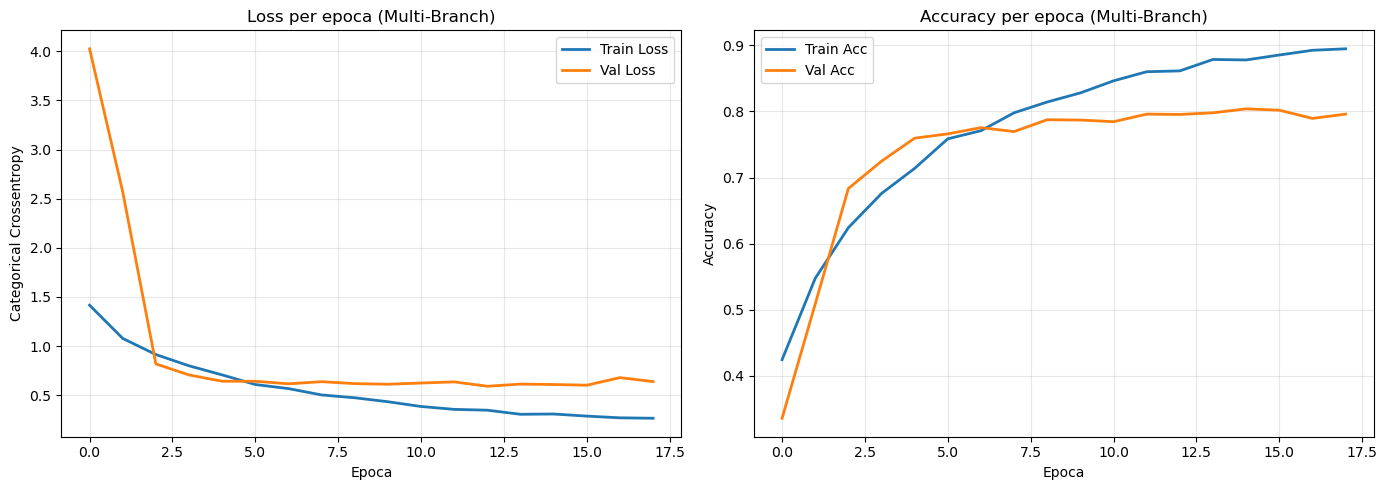

In [22]:
# ==========================================
# 1. Curve di apprendimento (Training vs Validation)
# ==========================================
# Utilizziamo l'oggetto 'history_multi' generato durante l'addestramento
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot della Loss
axes[0].plot(history_multi.history['loss'],     label='Train Loss', linewidth=2)
axes[0].plot(history_multi.history['val_loss'], label='Val Loss',   linewidth=2)
axes[0].set_title('Loss per epoca (Multi-Branch)'); axes[0].set_xlabel('Epoca'); axes[0].set_ylabel('Categorical Crossentropy')
axes[0].legend(); axes[0].grid(alpha=0.3)

# Plot dell'Accuracy
axes[1].plot(history_multi.history['accuracy'],     label='Train Acc', linewidth=2)
axes[1].plot(history_multi.history['val_accuracy'], label='Val Acc',   linewidth=2)
axes[1].set_title('Accuracy per epoca (Multi-Branch)'); axes[1].set_xlabel('Epoca'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [23]:

# ==========================================
# 2. Test evaluation + Confusion Matrix
# ==========================================
# Se vuoi assicurarti di usare i pesi migliori (se hai chiuso il notebook nel frattempo):
# best_multi_model = load_model('../models/best_multi_branch_cnn.keras')
# Altrimenti usiamo il modello appena addestrato nella RAM
best_multi_model = multi_branch_model

print("Valutazione del modello sul Test Set...")
# NOTA: Passiamo la lista test_inputs!
test_loss, test_acc = best_multi_model.evaluate(test_inputs, y_test, verbose=0)
print(f'Multi-Branch Test Loss     : {test_loss:.4f}')
print(f'Multi-Branch Test Accuracy : {test_acc * 100:.2f}%\n')

# Generazione delle predizioni
print("Generazione predizioni in corso...")
y_pred_proba = best_multi_model.predict(test_inputs, verbose=0)

# Convertiamo le probabilità predette in classi intere
y_pred = np.argmax(y_pred_proba, axis=1)

# Siccome per il Multi-Branch avevamo fatto il to_categorical su y_test, 
# dobbiamo riportare anche i target reali a interi per fare il confronto.
y_true = np.argmax(y_test, axis=1)


Valutazione del modello sul Test Set...
Multi-Branch Test Loss     : 0.5717
Multi-Branch Test Accuracy : 80.29%

Generazione predizioni in corso...


=== REPORT DI CLASSIFICAZIONE ===
              precision    recall  f1-score   support

     Disgust      0.672     0.677     0.675       285
        Fear      0.837     0.781     0.808       407
         Sad      0.774     0.795     0.784       533
     Neutral      0.839     0.837     0.838       443
       Happy      0.872     0.900     0.886       341

    accuracy                          0.803      2009
   macro avg      0.799     0.798     0.798      2009
weighted avg      0.803     0.803     0.803      2009



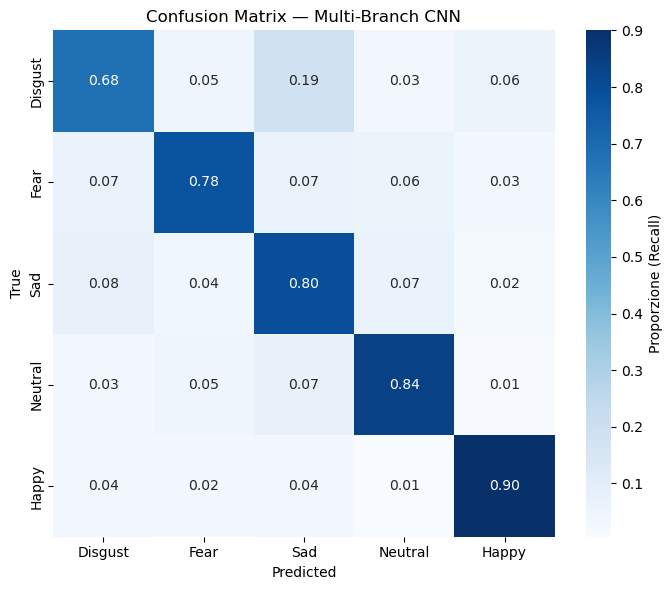

In [24]:

# ==========================================
# 3. Report e Matrice di Confusione
# ==========================================
print("=== REPORT DI CLASSIFICAZIONE ===")
print(classification_report(y_true, y_pred, target_names=EMOTION_LABELS, digits=3))

# Matrice di Confusione Normalizzata (Recall sulla diagonale)
cm = confusion_matrix(y_true, y_pred, normalize='true')

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS,
            cbar_kws={'label': 'Proporzione (Recall)'})
plt.title('Confusion Matrix — Multi-Branch CNN')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout()
plt.show()